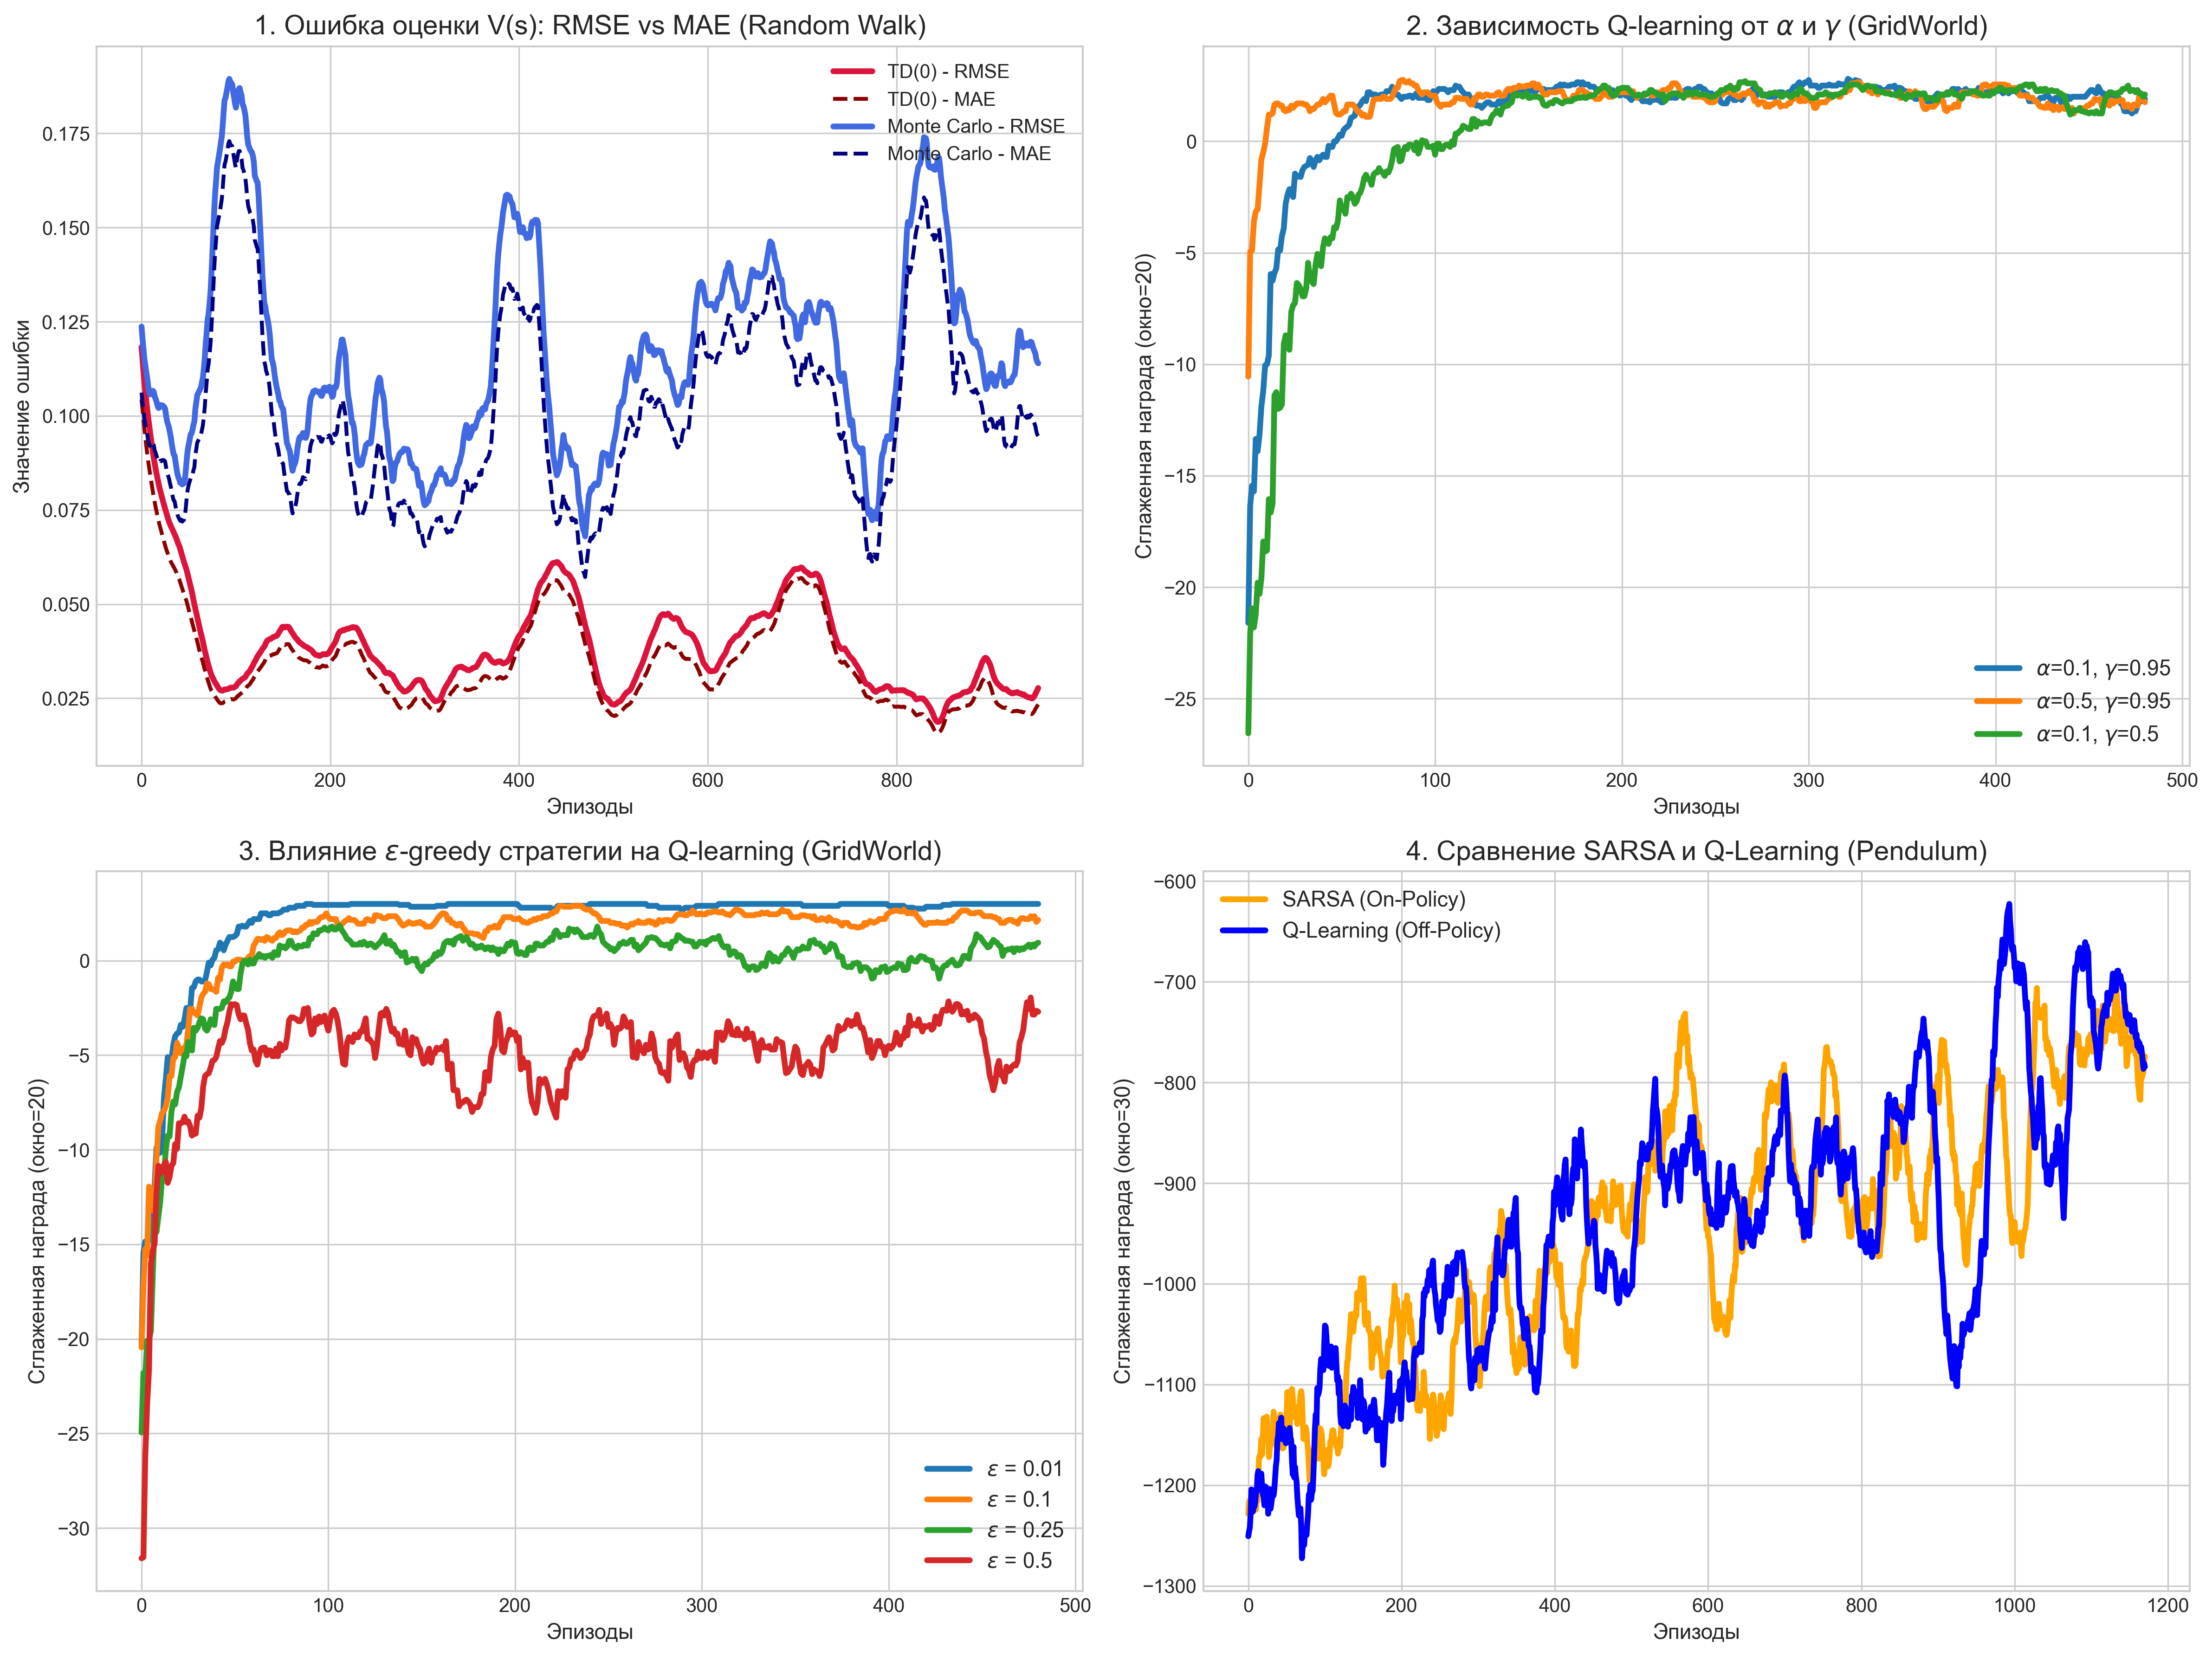

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import gymnasium as gym

class RandomWalkEnv:
    def __init__(self):
        self.reset()
    def reset(self):
        self.state = 3
        return self.state, {}
    def step(self, action):
        if action == 0:
            self.state -= 1
        else:
            self.state += 1
        done = self.state == 0 or self.state == 6
        reward = 1.0 if self.state == 6 else 0.0
        return self.state, reward, done, False, {}

class GridWorldEnv:
    def __init__(self):
        self.size = 5
        self.reset()
        
    def reset(self):
        self.x, self.y = 0, 0
        return (self.x, self.y), {}
        
    def step(self, action):
        if action == 0: self.y = min(self.size - 1, self.y + 1)
        elif action == 1: self.y = max(0, self.y - 1)
        elif action == 2: self.x = max(0, self.x - 1)
        elif action == 3: self.x = min(self.size - 1, self.x + 1)
        
        done = (self.x == self.size - 1 and self.y == self.size - 1)
        reward = 10.0 if done else -1.0
        return (self.x, self.y), reward, done, False, {}

class DiscretizedPendulumWrapper:
    def __init__(self, env_name='Pendulum-v1', n_bins=10, n_actions=5):
        self.env = gym.make(env_name)
        self.n_actions = n_actions
        self.action_space_discrete = np.linspace(-2.0, 2.0, n_actions)
        self.bins_cos = np.linspace(-1.0, 1.0, n_bins)
        self.bins_sin = np.linspace(-1.0, 1.0, n_bins)
        self.bins_vel = np.linspace(-8.0, 8.0, n_bins)

    def _discretize(self, state):
        cos_t, sin_t, vel = state
        return (np.digitize(cos_t, self.bins_cos), 
                np.digitize(sin_t, self.bins_sin), 
                np.digitize(vel, self.bins_vel))

    def reset(self):
        s, info = self.env.reset()
        return self._discretize(s), info

    def step(self, action_idx):
        action = [self.action_space_discrete[action_idx]]
        s_next, r, term, trunc, info = self.env.step(action)
        return self._discretize(s_next), r, term or trunc, False, info

class BaseAgent:
    def __init__(self, alpha=0.1, gamma=0.95, epsilon=0.1, n_actions=4):
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.n_actions = n_actions
        self.q_table = defaultdict(lambda: np.zeros(self.n_actions))
        self.v_table = np.zeros(7) + 0.5 

    def get_action(self, state):
        if np.random.random() < self.epsilon:
            return np.random.choice(self.n_actions)
        return np.argmax(self.q_table[state])

class MCAgent(BaseAgent):
    def update_episode(self, trajectory):
        G = 0
        for state, reward in reversed(trajectory):
            G = self.gamma * G + reward
            self.v_table[state] += self.alpha * (G - self.v_table[state])

class TD0Agent(BaseAgent):
    def update(self, state, reward, next_state, done):
        v_next = 0 if done else self.v_table[next_state]
        self.v_table[state] += self.alpha * (reward + self.gamma * v_next - self.v_table[state])

class SarsaAgent(BaseAgent):
    def update(self, state, action, reward, next_state, next_action, done):
        q_next = 0 if done else self.q_table[next_state][next_action]
        td_error = reward + self.gamma * q_next - self.q_table[state][action]
        self.q_table[state][action] += self.alpha * td_error

class QLearningAgent(BaseAgent):
    def update(self, state, action, reward, next_state, done):
        max_q_next = 0 if done else np.max(self.q_table[next_state])
        td_error = reward + self.gamma * max_q_next - self.q_table[state][action]
        self.q_table[state][action] += self.alpha * td_error

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, axs = plt.subplots(2, 2, figsize=(16, 12), dpi=300)

def moving_average(data, window=20):
    return [np.mean(data[i:i+window]) for i in range(len(data) - window + 1)]

true_v = np.array([0, 1/6, 2/6, 3/6, 4/6, 5/6, 1])
env_rw = RandomWalkEnv()
rw_episodes = 1000

def run_rw(agent, is_mc=False, episodes=1000):
    rmse_errors = []
    mae_errors = []
    agent.v_table[1:6] = 0.5
    agent.v_table[0], agent.v_table[6] = 0.0, 0.0
    
    for ep in range(episodes):
        s, _ = env_rw.reset()
        trajectory = []
        done = False
        while not done:
            a = np.random.choice(2)
            s_next, r, done, _, _ = env_rw.step(a)
            if is_mc:
                trajectory.append((s, r))
            else:
                agent.update(s, r, s_next, done)
            s = s_next
        if is_mc:
            agent.update_episode(trajectory)
        rmse = np.sqrt(np.mean((agent.v_table[1:6] - true_v[1:6])**2))
        mae = np.mean(np.abs(agent.v_table[1:6] - true_v[1:6]))
        
        rmse_errors.append(rmse)
        mae_errors.append(mae)
        
    return rmse_errors, mae_errors

td0_rmse, td0_mae = run_rw(TD0Agent(alpha=0.05, gamma=1.0, epsilon=0), is_mc=False, episodes=rw_episodes)
mc_rmse, mc_mae = run_rw(MCAgent(alpha=0.05, gamma=1.0, epsilon=0), is_mc=True, episodes=rw_episodes)

axs[0, 0].plot(moving_average(td0_rmse, 50), label='TD(0) - RMSE', color='crimson', lw=3, linestyle='-')
axs[0, 0].plot(moving_average(td0_mae, 50), label='TD(0) - MAE', color='darkred', lw=2, linestyle='--')
axs[0, 0].plot(moving_average(mc_rmse, 50), label='Monte Carlo - RMSE', color='royalblue', lw=3, linestyle='-')
axs[0, 0].plot(moving_average(mc_mae, 50), label='Monte Carlo - MAE', color='navy', lw=2, linestyle='--')

axs[0, 0].set_title("1. Ошибка оценки V(s): RMSE vs MAE (Random Walk)", fontsize=14)
axs[0, 0].set_xlabel("Эпизоды", fontsize=11)
axs[0, 0].set_ylabel("Значение ошибки", fontsize=11)
axs[0, 0].legend(fontsize=10, loc='upper right')

env_grid = GridWorldEnv()
grid_episodes = 500
params = [(0.1, 0.95), (0.5, 0.95), (0.1, 0.5)]

for alpha, gamma in params:
    rewards = []
    agent = QLearningAgent(alpha=alpha, gamma=gamma, epsilon=0.1, n_actions=4)
    for ep in range(grid_episodes):
        s, _ = env_grid.reset()
        ep_r, done = 0, False
        while not done:
            a = agent.get_action(s)
            s_next, r, done, _, _ = env_grid.step(a)
            agent.update(s, a, r, s_next, done)
            ep_r += r
            s = s_next
        rewards.append(ep_r)
    axs[0, 1].plot(moving_average(rewards, 20), label=f'$\\alpha$={alpha}, $\\gamma$={gamma}', lw=3)

axs[0, 1].set_title("2. Зависимость Q-learning от $\\alpha$ и $\\gamma$ (GridWorld)", fontsize=14)
axs[0, 1].set_xlabel("Эпизоды", fontsize=11)
axs[0, 1].set_ylabel("Сглаженная награда ", fontsize=11)
axs[0, 1].legend(fontsize=11)

epsilons = [0.01, 0.1, 0.25 ,0.5]
for eps in epsilons:
    agent = QLearningAgent(alpha=0.1, gamma=0.95, epsilon=eps, n_actions=4)
    rewards_eps = []
    for ep in range(grid_episodes):
        s, _ = env_grid.reset()
        ep_r, done = 0, False
        while not done:
            a = agent.get_action(s)
            s_next, r, done, _, _ = env_grid.step(a)
            agent.update(s, a, r, s_next, done)
            ep_r += r
            s = s_next
        rewards_eps.append(ep_r)
    axs[1, 0].plot(moving_average(rewards_eps, 20), label=f'$\\epsilon$ = {eps}', lw=3)

axs[1, 0].set_title("3. Влияние $\\epsilon$-greedy стратегии на Q-learning (GridWorld)", fontsize=14)
axs[1, 0].set_xlabel("Эпизоды", fontsize=11)
axs[1, 0].set_ylabel("Сглаженная награда ", fontsize=11)
axs[1, 0].legend(fontsize=11)


env_pend = DiscretizedPendulumWrapper(n_bins=8, n_actions=5)
pend_episodes = 1200
sarsa = SarsaAgent(alpha=0.1, gamma=0.95, epsilon=0.1, n_actions=5)
q_learn = QLearningAgent(alpha=0.1, gamma=0.95, epsilon=0.1, n_actions=5)

sarsa_rewards, q_rewards = [], []

for ep in range(pend_episodes):

    s, _ = env_pend.reset()
    a = sarsa.get_action(s)
    ep_r = 0
    for _ in range(200):
        s_next, r, done, _, _ = env_pend.step(a)
        a_next = sarsa.get_action(s_next)
        sarsa.update(s, a, r, s_next, a_next, done)
        ep_r += r
        s, a = s_next, a_next
        if done: break
    sarsa_rewards.append(ep_r)

    s, _ = env_pend.reset()
    ep_r = 0
    for _ in range(200):
        a = q_learn.get_action(s)
        s_next, r, done, _, _ = env_pend.step(a)
        q_learn.update(s, a, r, s_next, done)
        ep_r += r
        s = s_next
        if done: break
    q_rewards.append(ep_r)

axs[1, 1].plot(moving_average(sarsa_rewards, 30), label='SARSA (On-Policy)', color='orange', lw=3)
axs[1, 1].plot(moving_average(q_rewards, 30), label='Q-Learning (Off-Policy)', color='blue', lw=3)
axs[1, 1].set_title("4. Сравнение SARSA и Q-Learning (Pendulum)", fontsize=14)
axs[1, 1].set_xlabel("Эпизоды", fontsize=11)
axs[1, 1].set_ylabel("Сглаженная награда", fontsize=11)
axs[1, 1].legend(fontsize=11)

plt.tight_layout()
plt.savefig("clear_plots_rmse_mae_report.png", dpi=300, bbox_inches='tight')
plt.show()